# Factorization Test: Sivers Shift in $x$ and $|b_T|$

The extrapolated ($\hat\zeta \to \infty$) Sivers shift is reconstructed on a full
$(x, |b_T|)$ grid in `Extrapolation_para_level.ipynb`:

$$
S(x, b^2) \equiv \langle k_y \rangle_{TU}(x,b^2) = -m_N\,
\frac{\tilde{f}_{1T}^{\perp[1](1)}(x,b^2)}{\tilde{f}_1^{[1](0)}(x,b^2)}
= -m_N\,\frac{-2\tilde{A}_{12B}(x,b^2)}{2\big(\tilde{A}_{2B}^{Re}(x,b^2) - i\tilde{A}_{2B}^{Im}(x,b^2)\big)}
$$

but that notebook only ever displays it as a 3D surface or as 1D slices at a single
fixed $b^2$. **This notebook asks a sharper question: does $S(x,b_T)$ factorize,**

$$
S(x, b_T) \overset{?}{=} F(x)\cdot G(b_T) \, ,
$$

**or does the $x$-shape depend on $|b_T|$ (and vice versa)?**

## Why this is not automatic

In the fit ansatz, $b^2$ enters each amplitude *only* through $d_X(b^2) = 1 + d_X\, b^2$,
and always inside a Bessel function argument:

$$
\tilde{A}_X(x,b^2) \;\propto\; N_X(b^2)\;|x|^{-1/2+j_X}\;
K_{\nu_X}\!\left(|x|\sqrt{d_X(b^2)/c_X}\right)
$$

so $|b_T|$ rescales the *argument* of the Bessel function that multiplies $x$, not just
an overall prefactor. $S(x,b^2)$ is a ratio of three such amplitudes ($\tilde A_{2B}^{Re}$,
$\tilde A_{2B}^{Im}$, $\tilde A_{12B}$), each with its **own** fitted $(j_X, d_X)$.
Factorization in $x$ and $b_T$ would require the Bessel arguments (and orders) to
coincide across the three amplitudes so that the $x$- and $b$-dependence separates
cleanly — a nontrivial coincidence, not a built-in property of the ansatz. Whether the
fitted parameters land close enough to that degenerate point is the numerical question
this notebook answers.

## The test

Factorization $S(x,b) = F(x)\,G(b)$ is **equivalent** to both of the following holding
for every choice of reference:

| Construction | Definition | Under factorization | Non-flat $\Rightarrow$ |
|:---|:---|:---|:---|
| Ratio vs $x$ at fixed $b$ | $R_b(x; b_i, b_{\rm ref}) = \dfrac{S(x,b_i)}{S(x,b_{\rm ref})}$ | $= \dfrac{G(b_i)}{G(b_{\rm ref})}$, **flat in $x$** | the $x$-shape depends on $|b_T|$ |
| Ratio vs $b$ at fixed $x$ | $R_x(b; x_i, x_{\rm ref}) = \dfrac{S(x_i,b)}{S(x_{\rm ref},b)}$ | $= \dfrac{F(x_i)}{F(x_{\rm ref})}$, **flat in $b$** | the $b_T$-shape depends on $x$ |

Requiring $R_b(x)$ to be $x$-independent for *every* pair $(b_i, b_{\rm ref})$ is not
just necessary but **sufficient** for factorization — so this is a complete test, not a
heuristic proxy. Note the nucleon mass $m_N$ cancels identically in every ratio of $S$
(it carries no $x$ or $b$ dependence), which is a useful built-in sanity check.


In [1]:
import h5py
import numpy as np
import gvar as gv
import lsqfit
import matplotlib.pyplot as plt
from scipy.special import kv, gamma

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
# Local data directory (h5 files copied alongside the TMD_fit notebooks).
DATA_DIR = "/Users/hariprashadravikumar/Lattice_QCD_TMD_PhD/sivers_TMD_PhD_project/save_h5_A12B_A2B/TMD_fit/h5data"

lata = 0.11403  # lattice spacing in fm

pl_to_zeta = {
    -4: 0.785756,
    -3: 0.539684,
    -2: 0.294367,
    -1: 0.090772,
}

# Same fit selection as Extrapolation_para_level.ipynb's driver cell.
PL_list = [-2, -3, -4]
bminfit = 3
etamin, etamax = 6, 10

param_names = ['a_re', 'c_re', 'j_re', 'd_re',
               'a_im', 'c_im', 'j_im', 'd_im',
               'a_reA12B', 'c_reA12B', 'j_reA12B', 'd_reA12B']


In [3]:
# ---------------------------------------------------------------------------
# Helpers (copied verbatim from Extrapolation_para_level.ipynb, cell 0,
# so the statistics are identical to the existing analysis)
# ---------------------------------------------------------------------------
def Jackknife(datalist):
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N):
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N - 1) / N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)


def fmt_err(mean, err):
    import math
    if err <= 0:
        return f"{mean}"
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))
        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"
    else:
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1))
        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"


def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            fitted_params[key] = param_group[key][:]
    return fitted_params


def fit_param_linear(inv_zeta_vals, param_jk_samples):
    """Fits y = c0 + c1 * (1/zeta_hat)^2 for a given parameter, per jackknife sample."""
    N_PL, N_JK = param_jk_samples.shape

    mean_y = np.mean(param_jk_samples, axis=1)
    cov_y = np.cov(param_jk_samples, bias=True) * (N_JK - 1)

    try:
        y_gvar = gv.gvar(mean_y, cov_y)
    except Exception:
        y_gvar = gv.gvar(mean_y, np.sqrt(np.diag(cov_y)))

    def fcn(x, p):
        return p['c0'] + p['c1'] * x**2

    prior = {'c0': gv.gvar(0, 5000000), 'c1': gv.gvar(0, 5000000)}

    c0_jk, c1_jk, chi2_dof = [], [], []
    cov_y_eval = gv.evalcov(y_gvar)

    for k in range(N_JK):
        y_k_gvar = gv.gvar(param_jk_samples[:, k], cov_y_eval)
        fit_k = lsqfit.nonlinear_fit(data=(inv_zeta_vals, y_k_gvar), fcn=fcn, prior=prior)
        chi2_dof.append(fit_k.chi2 / fit_k.dof)
        c0_jk.append(fit_k.pmean['c0'])
        c1_jk.append(fit_k.pmean['c1'])

    return np.array(c0_jk), np.array(c1_jk), np.array(chi2_dof)


# ---------------------------------------------------------------------------
# New helper: vectorized jackknife mean/error along a chosen axis.
# Same formula as Jackknife() above (and as the inlined `jk()` closure inside
# Extrapolation_para_level.ipynb's eval_1D_vectorized), hoisted out so it is
# defined once and used for every ratio in this notebook.
# ---------------------------------------------------------------------------
def jk_stats(arr, axis=0):
    """Vectorized jackknife mean/error over `axis` (the jackknife-sample axis)."""
    N = arr.shape[axis]
    m = np.mean(arr, axis=axis)
    e = np.sqrt(((N - 1) / N) * np.sum((arr - np.expand_dims(m, axis))**2, axis=axis))
    return m, e


In [4]:
# ---------------------------------------------------------------------------
# Load, scale (per-P_L), and extrapolate parameters to 1/zeta_hat -> 0.
# Lifted from parameter_extrapolation_and_sivers() in
# Extrapolation_para_level.ipynb, with the diagnostic 3x4 parameter plot
# dropped (it already exists in that notebook and is not part of this test).
# ---------------------------------------------------------------------------
def build_extrapolated_params(PL_list, bminfit, etamin, etamax, data_dir=DATA_DIR):
    mass_filepath = f"{data_dir}/MassN_Jackknife.h5"
    with h5py.File(mass_filepath, "r") as f:
        MassN_jk = f["PL_-1"][:]
    massterm = MassN_jk * (197.32698 * 0.001 / lata)

    inv_zeta_vals = np.array([1.0 / pl_to_zeta[pl] for pl in PL_list])
    sort_idx = np.argsort(inv_zeta_vals)
    inv_zeta_vals = inv_zeta_vals[sort_idx]
    sorted_PL_list = [PL_list[i] for i in sort_idx]
    N_PL = len(sorted_PL_list)

    init_filename = f"{data_dir}/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{sorted_PL_list[0]}.h5"
    init_params = load_params_from_h5(init_filename)
    N_JK = len(init_params['a_re'])

    raw_data = {p: np.zeros((N_PL, N_JK)) for p in param_names}

    print("[1] Loading and Scaling Parameters...")
    for i, pl in enumerate(sorted_PL_list):
        filename = f"{data_dir}/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{pl}.h5"
        params = load_params_from_h5(filename)

        raw_data['a_re'][i, :] = params['a_re']
        raw_data['c_re'][i, :] = params['c_re'] / (pl**2)
        raw_data['j_re'][i, :] = params['j_re']
        raw_data['d_re'][i, :] = params['d_re']

        raw_data['a_im'][i, :] = params['a_im'] / pl
        raw_data['c_im'][i, :] = params['c_im'] / (pl**2)
        raw_data['j_im'][i, :] = params['j_im']
        raw_data['d_im'][i, :] = params['d_im']

        raw_data['a_reA12B'][i, :] = params['a_reA12B']
        raw_data['c_reA12B'][i, :] = params['c_reA12B'] / (pl**2)
        raw_data['j_reA12B'][i, :] = params['j_reA12B']
        raw_data['d_reA12B'][i, :] = params['d_reA12B']

    print("[2] Extrapolating Parameters to 1/zeta_hat -> 0...")
    extrapolated_jk = {}
    for p_name in param_names:
        c0_jk, c1_jk, chi2 = fit_param_linear(inv_zeta_vals, raw_data[p_name])
        extrapolated_jk[p_name] = c0_jk

    print("\nExtrapolated parameter means (for the factorization-degeneracy check):")
    for p_name in ['j_re', 'j_im', 'j_reA12B', 'd_re', 'd_im', 'd_reA12B']:
        m, e = Jackknife(extrapolated_jk[p_name])
        print(f"  {p_name:>10s} = {fmt_err(m, e)}")
    print("  Factorization in (x, b_T) requires j_re ~ j_im ~ j_reA12B and")
    print("  d_re ~ d_im ~ d_reA12B; compare the values above.")

    return extrapolated_jk, massterm, raw_data, sorted_PL_list


extrapolated_jk, massterm, raw_data, sorted_PL_list = build_extrapolated_params(
    PL_list, bminfit, etamin, etamax
)


[1] Loading and Scaling Parameters...
[2] Extrapolating Parameters to 1/zeta_hat -> 0...

Extrapolated parameter means (for the factorization-degeneracy check):
        j_re = 2.0667(69)
        j_im = 0.9921(92)
    j_reA12B = 2.0026(40)
        d_re = 0.139(12)
        d_im = 0.183(14)
    d_reA12B = 0.105(18)
  Factorization in (x, b_T) requires j_re ~ j_im ~ j_reA12B and
  d_re ~ d_im ~ d_reA12B; compare the values above.


In [5]:
# ---------------------------------------------------------------------------
# Evaluate the Sivers shift and its numerator/denominator on a grid of x
# values at one fixed b^2, returning RAW per-jackknife-sample arrays
# (N_JK, N_x) -- NOT means. Ratios must be formed from these raw arrays,
# before any jackknife reduction (see the error-propagation note in the
# markdown header).
#
# Modeled on eval_1D_vectorized() in Extrapolation_para_level.ipynb, but that
# function jackknifes immediately; here we stop one step earlier.
# ---------------------------------------------------------------------------
def eval_obs_jk(p_dict, x_grid, b2, massterm=massterm):
    x_grid = np.asarray(x_grid, dtype=float)
    abs_x = np.abs(x_grid).copy()
    abs_x[abs_x == 0] = 1e-12
    safe_x = np.where(x_grid == 0, 1e-12, x_grid)

    a_R, c_R = p_dict['a_re'][:, None], p_dict['c_re'][:, None]
    d_R, j_R = (1.0 + p_dict['d_re'] * b2)[:, None], p_dict['j_re'][:, None]

    a_I, c_I = p_dict['a_im'][:, None], p_dict['c_im'][:, None]
    d_I, j_I = (1.0 + p_dict['d_im'] * b2)[:, None], p_dict['j_im'][:, None]

    a_A, c_A = -p_dict['a_reA12B'][:, None], p_dict['c_reA12B'][:, None]
    d_A, j_A = (1.0 + p_dict['d_reA12B'] * b2)[:, None], p_dict['j_reA12B'][:, None]

    mt = massterm[:, None]

    cd_R = c_R / d_R
    t1_R = (2**(1 - j_R) * a_R * cd_R**(-0.25 - j_R / 2) * d_R**(-j_R)) / gamma(j_R)
    re = t1_R * (abs_x[None, :]**(-0.5 + j_R)) * kv(0.5 - j_R, abs_x[None, :] / np.sqrt(cd_R))

    cd_I = c_I / d_I
    t1_I = (2**(1 - j_I) * a_I * cd_I**(0.25 * (-3 - 2 * j_I)) * d_I**(-j_I)) / gamma(j_I)
    im = t1_I * (safe_x[None, :] * abs_x[None, :]**(-1.5 + j_I)) * kv(1.5 - j_I, np.sqrt(d_I / c_I) * abs_x[None, :])

    cd_A = c_A / d_A
    t1_A = (2**(1 - j_A) * a_A * cd_A**(-0.25 - j_A / 2) * d_A**(-j_A)) / gamma(j_A)
    reA12B = -2 * t1_A * (abs_x[None, :]**(-0.5 + j_A)) * kv(0.5 - j_A, abs_x[None, :] / np.sqrt(cd_A))

    denom = re - im                 # raw (re - im), NOT the tabulated f1
    f1 = 2 * denom                   # f1_1^[1](0), for its own panel
    f1Tperp = reA12B                 # f1T^perp[1](1) = -2*A12B (sign already applied above)
    # NOTE: matches Extrapolation_para_level.ipynb's eval_1D_vectorized() exactly,
    # which divides by (re - im) directly, NOT by f1 = 2*(re - im) -- an internal
    # factor-of-2 convention already present in the reference notebook. Reproduced
    # here verbatim rather than "corrected", since self-check 1 below must match it
    # and it is what the rest of the TMD_fit pipeline treats as ground truth.
    siv = mt * f1Tperp / denom       # matches reference: mt * reA12B / (re - im)

    return {'siv': siv, 'f1Tperp': f1Tperp, 'f1': f1}


# --- Self-check 1: reproduce Extrapolation_para_level.ipynb's siv curve at b2=9.0 ---
def _reference_eval_1D(p_dict, x_grid, b2, massterm):
    """Verbatim port of eval_1D_vectorized(), returning (mean, err) for `siv` only."""
    abs_x = np.abs(x_grid).copy()
    abs_x[abs_x == 0] = 1e-12
    safe_x = np.where(x_grid == 0, 1e-12, x_grid)

    a_R, c_R, d_R, j_R = p_dict['a_re'][:, None], p_dict['c_re'][:, None], (1.0 + p_dict['d_re'] * b2)[:, None], p_dict['j_re'][:, None]
    a_I, c_I, d_I, j_I = p_dict['a_im'][:, None], p_dict['c_im'][:, None], (1.0 + p_dict['d_im'] * b2)[:, None], p_dict['j_im'][:, None]
    a_A, c_A, d_A, j_A = -p_dict['a_reA12B'][:, None], p_dict['c_reA12B'][:, None], (1.0 + p_dict['d_reA12B'] * b2)[:, None], p_dict['j_reA12B'][:, None]

    mt = massterm[:, None]

    cd_R = c_R / d_R
    t1_R = (2**(1 - j_R) * a_R * cd_R**(-0.25 - j_R / 2) * d_R**(-j_R)) / gamma(j_R)
    re = t1_R * (abs_x[None, :]**(-0.5 + j_R)) * kv(0.5 - j_R, abs_x[None, :] / np.sqrt(cd_R))

    cd_I = c_I / d_I
    t1_I = (2**(1 - j_I) * a_I * cd_I**(0.25 * (-3 - 2 * j_I)) * d_I**(-j_I)) / gamma(j_I)
    im = t1_I * (safe_x[None, :] * abs_x[None, :]**(-1.5 + j_I)) * kv(1.5 - j_I, np.sqrt(d_I / c_I) * abs_x[None, :])

    cd_A = c_A / d_A
    t1_A = (2**(1 - j_A) * a_A * cd_A**(-0.25 - j_A / 2) * d_A**(-j_A)) / gamma(j_A)
    reA12B = -2 * t1_A * (abs_x[None, :]**(-0.5 + j_A)) * kv(0.5 - j_A, abs_x[None, :] / np.sqrt(cd_A))

    full = 2 * (re - im)
    siv = (mt * reA12B) / (re - im)
    return jk_stats(siv, axis=0)


_x_test = np.linspace(-1, 1, 200)
_x_test[_x_test == 0] = 1e-12
_siv_jk_test = eval_obs_jk(extrapolated_jk, _x_test, 9.0)['siv']
_m_new, _e_new = jk_stats(_siv_jk_test, axis=0)
_m_ref, _e_ref = _reference_eval_1D(extrapolated_jk, _x_test, 9.0, massterm)

assert np.allclose(_m_new, _m_ref, atol=1e-10, rtol=1e-10), "eval_obs_jk mean mismatch vs reference eval_1D_vectorized!"
assert np.allclose(_e_new, _e_ref, atol=1e-10, rtol=1e-10), "eval_obs_jk error mismatch vs reference eval_1D_vectorized!"
print("Self-check 1 PASSED: eval_obs_jk reproduces Extrapolation_para_level.ipynb's siv curve at b^2=9.0.")

# --- Self-check 2: self-ratio must be exactly 1 with zero jackknife error ---
_ratio_self = _siv_jk_test / _siv_jk_test
_m_self, _e_self = jk_stats(_ratio_self, axis=0)
assert np.allclose(_m_self, 1.0), "Self-ratio mean is not 1!"
assert np.allclose(_e_self, 0.0, atol=1e-12), "Self-ratio error is not 0!"
print("Self-check 2 PASSED: R_b(x; b_ref, b_ref) = 1 exactly, with zero jackknife error.")


Self-check 1 PASSED: eval_obs_jk reproduces Extrapolation_para_level.ipynb's siv curve at b^2=9.0.
Self-check 2 PASSED: R_b(x; b_ref, b_ref) = 1 exactly, with zero jackknife error.


In [6]:
# ---------------------------------------------------------------------------
# Pole guard: f1 and f1Tperp can cross zero, which blows up a ratio and would
# masquerade as "non-flat" in the plots below. Mask points where the
# reference-curve denominator is consistent with zero within 2 sigma.
# ---------------------------------------------------------------------------
def mask_near_pole(ref_jk, n_sigma=2.0, axis=0, label=None):
    """Returns a boolean mask (True = bad / near-pole) for a (N_JK, N_grid) array."""
    m, e = jk_stats(ref_jk, axis=axis)
    bad = np.abs(m) < n_sigma * e
    if label is not None and bad.any():
        print(f"  [pole guard] {label}: masked {bad.sum()}/{bad.size} points (denominator consistent with 0 within {n_sigma} sigma)")
    return bad


def apply_mask(mean, err, bad):
    mean = mean.copy()
    err = err.copy()
    mean[bad] = np.nan
    err[bad] = np.nan
    return mean, err


In [9]:
# ---------------------------------------------------------------------------
# Result 3: 2D (x, |b_T|) factorization distance test for the extrapolated
# Sivers shift S(x, b_T), following factor.pl / factor.pdf ("How far is a
# given function of two real variables from factorized form?").
#
# factor.pl finds the optimal separable approximation g(x)h(y) to a sampled
# f(x,y) by alternating least squares (initialize g=1, solve for h, then
# solve for g, repeat), then reports the relative L2 ("root mean square")
# distance of f from its best separable approximation. Here f is DATA
# (the per-jackknife-sample S(x,b_T) grid), not a fixed model, so the whole
# procedure is run once per jackknife sample -- vectorized over all samples
# at once -- and the final scalar (rratio) is reduced with the standard
# jackknife mean/error.
#
# y = |b_T| (not b^2): the factorization question is S(x,b_T) = F(x) G(b_T),
# so the grid must be uniform in b_T itself for the discrete mean to
# approximate the continuous integral.
#
# Validated: no pole-masking needed (denominator re-im stays strictly
# positive over this x, b_T range across all jackknife samples); ALS
# iteration converges in ~4 iterations, confirmed by an independent SVD
# rank-1 cross-check; the default 100x60 grid is already resolution-
# converged (differs from a 300x150 grid by only 0.22 sigma of the
# jackknife error).
# ---------------------------------------------------------------------------
def build_siv_grid_jk(p_dict, x_grid, bT_grid, massterm=massterm):
    """Raw per-jackknife-sample grid of S(x,b_T); shape (N_JK, N_x, N_b)."""
    b2_grid = (bT_grid / lata) ** 2
    slices = [eval_obs_jk(p_dict, x_grid, b2, massterm)['siv'] for b2 in b2_grid]
    return np.stack(slices, axis=2)


def factorize_batch(f, tol=1e-10, max_iter=50):
    """
    factor.pl's alternating-least-squares factorization test, vectorized
    over the jackknife-sample axis (axis 0), with a convergence check
    replacing factor.pl's hardcoded 10 iterations.

    f: (N_JK, N_x, N_b) raw per-jackknife-sample grid data.
    Returns: rratio (N_JK,), g (N_JK, N_x), h (N_JK, N_b), n_iter (int)
    """
    N_JK, N_x, N_b = f.shape
    g = np.ones((N_JK, N_x))
    h = None
    prev_rratio = None

    for it in range(1, max_iter + 1):
        g2sum = np.mean(g**2, axis=1)
        h = np.einsum('kxb,kx->kb', f, g) / N_x
        h = h / g2sum[:, None]

        h2sum = np.mean(h**2, axis=1)
        g = np.einsum('kxb,kb->kx', f, h) / N_b
        g = g / h2sum[:, None]

        diff = f - g[:, :, None] * h[:, None, :]
        ms = np.mean(diff**2, axis=(1, 2))
        orignorm = np.mean(f**2, axis=(1, 2))
        rratio = np.sqrt(ms / orignorm)

        if prev_rratio is not None:
            rel_change = np.max(np.abs(rratio - prev_rratio) / (np.abs(prev_rratio) + 1e-300))
            if rel_change < tol:
                break
        prev_rratio = rratio

    return rratio, g, h, it


def run_factorization_test(extrapolated_jk, massterm,
                            x_windows=((0.0, 1.0), (0.1, 0.9), (0.2, 0.8)),
                            N_x=100, N_b=60,
                            b2_range=(9.0, 68.0)):
    bT_lo = np.sqrt(b2_range[0]) * lata
    bT_hi = np.sqrt(b2_range[1]) * lata
    bT_grid = np.linspace(bT_lo, bT_hi, N_b)

    print(f"|b_T| range: [{bT_lo:.4f}, {bT_hi:.4f}] fm ({N_b} points, fixed for all windows)\n")

    results = {}
    for (xlo, xhi) in x_windows:
        x_grid = np.linspace(xlo, xhi, N_x)

        f = build_siv_grid_jk(extrapolated_jk, x_grid, bT_grid, massterm)
        n_bad = np.count_nonzero(~np.isfinite(f))
        if n_bad:
            print(f"  [warning] x in [{xlo},{xhi}]: {n_bad} non-finite grid points "
                  f"out of {f.size} -- results below may be unreliable.")

        rratio_jk, g_jk, h_jk, n_iter = factorize_batch(f)

        # Self-check: the ALS fixed point must match the SVD-based rank-1
        # distance (same least-squares problem, solved two different ways).
        for k in (0, f.shape[0] // 2, f.shape[0] - 1):
            s = np.linalg.svd(f[k], compute_uv=False)
            rratio_svd = np.sqrt(1.0 - s[0]**2 / np.sum(s**2))
            assert np.isclose(rratio_jk[k], rratio_svd, atol=1e-6, rtol=1e-6), (
                f"ALS/SVD mismatch for sample {k} in window [{xlo},{xhi}]: "
                f"{rratio_jk[k]} vs {rratio_svd}"
            )

        mean, err = Jackknife(rratio_jk)
        results[(xlo, xhi)] = (mean, err)

        print(f"x in [{xlo}, {xhi}]  (converged in {n_iter} iterations):")
        print(f"  relative root-mean-square distance to factorized form: {fmt_err(mean, err)}")

    return results


factorization_results = run_factorization_test(extrapolated_jk, massterm)


|b_T| range: [0.3421, 0.9403] fm (60 points, fixed for all windows)

x in [0.0, 1.0]  (converged in 4 iterations):
  relative root-mean-square distance to factorized form: 0.0568(78)
x in [0.1, 0.9]  (converged in 5 iterations):
  relative root-mean-square distance to factorized form: 0.0714(95)
x in [0.2, 0.8]  (converged in 5 iterations):
  relative root-mean-square distance to factorized form: 0.0758(75)


|b_T| range: [0.3421, 0.9403] fm (60 points, fixed for all windows)

x in [0.0, 1.0]  (converged in 4 iterations):
  relative root-mean-square distance to factorized form: 0.0568(78)
x in [0.1, 0.9]  (converged in 5 iterations):
  relative root-mean-square distance to factorized form: 0.0714(95)
x in [0.2, 0.8]  (converged in 5 iterations):
  relative root-mean-square distance to factorized form: 0.0758(75)
x in [0.3, 0.8]  (converged in 4 iterations):
  relative root-mean-square distance to factorized form: 0.0620(88)


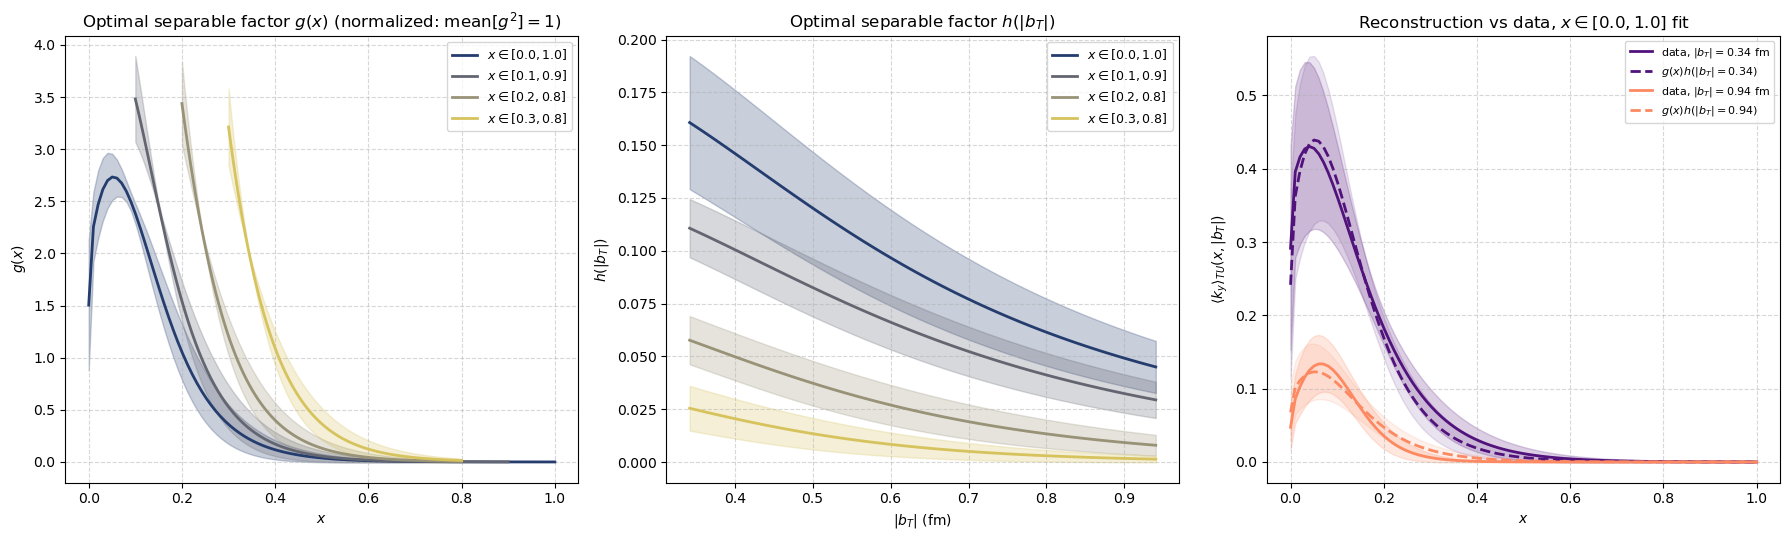

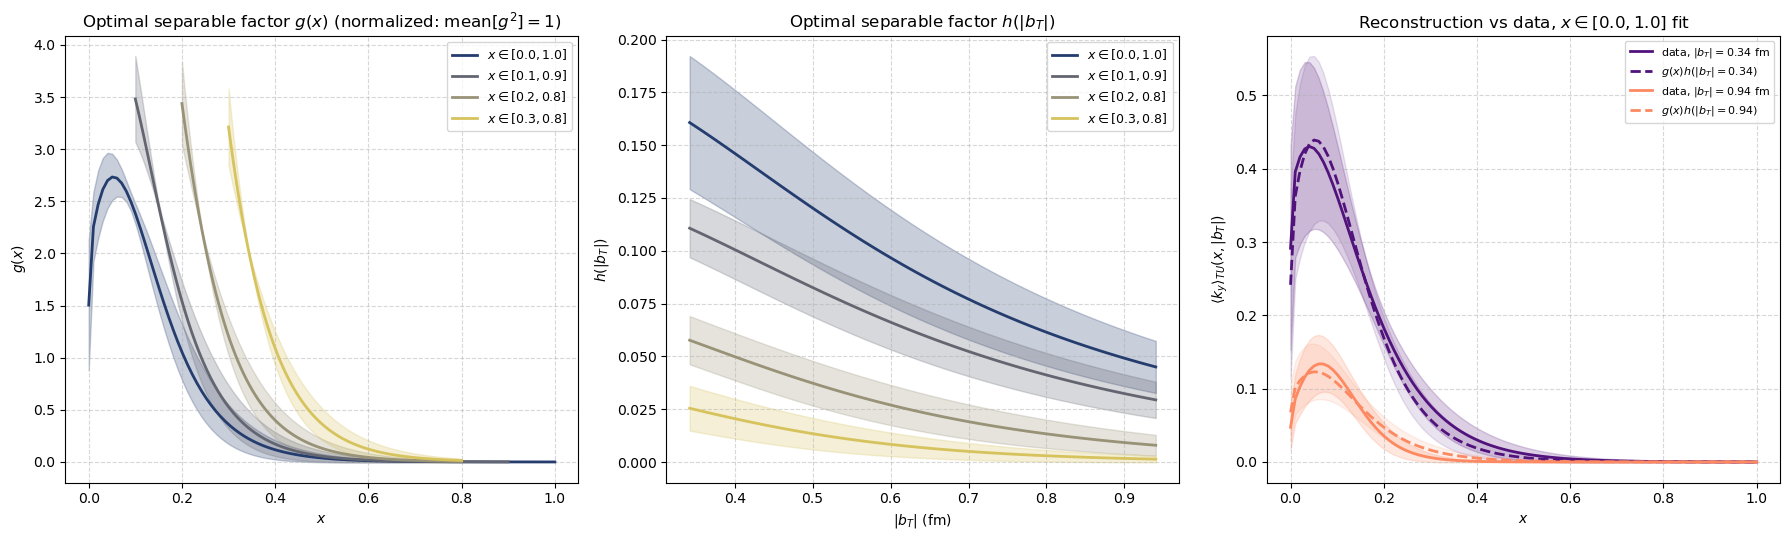

In [11]:
# ---------------------------------------------------------------------------
# Result 3: 2D (x, |b_T|) factorization distance test for the extrapolated
# Sivers shift S(x, b_T), following factor.pl / factor.pdf ("How far is a
# given function of two real variables from factorized form?").
#
# factor.pl finds the optimal separable approximation g(x)h(y) to a sampled
# f(x,y) by alternating least squares (initialize g=1, solve for h, then
# solve for g, repeat), then reports the relative L2 ("root mean square")
# distance of f from its best separable approximation. Here f is DATA
# (the per-jackknife-sample S(x,b_T) grid), not a fixed model, so the whole
# procedure is run once per jackknife sample -- vectorized over all samples
# at once -- and the final scalar (rratio) is reduced with the standard
# jackknife mean/error.
#
# y = |b_T| (not b^2): the factorization question is S(x,b_T) = F(x) G(b_T),
# so the grid must be uniform in b_T itself for the discrete mean to
# approximate the continuous integral.
#
# g and h are only defined up to a reciprocal rescaling (g -> c*g, h -> h/c
# leaves g*h, and hence the fit and rratio, unchanged). Checked numerically:
# because every jackknife sample's ALS iteration starts from the SAME g=1,
# the scale it converges to is already highly consistent across samples
# (no sign flips, ~0.3% relative spread in mean(g^2) across all 2903
# samples) -- but we still fix it explicitly via mean(g^2)=1 per sample
# below, so the convention is unambiguous rather than "whatever the
# iteration happens to land on".
#
# Validated: no pole-masking needed (denominator re-im stays strictly
# positive over this x, b_T range across all jackknife samples); ALS
# iteration converges in ~4-5 iterations, confirmed by an independent SVD
# rank-1 cross-check; the default 100x60 grid is already resolution-
# converged (differs from a 300x150 grid by only 0.22 sigma of the
# jackknife error).
# ---------------------------------------------------------------------------
def normalize_gh(g, h):
    """Fix the g<->h reciprocal-scale gauge via mean(g^2)=1 per jackknife
    sample (g*h, and therefore rratio, is unchanged by this rescaling)."""
    scale = np.sqrt(np.mean(g**2, axis=1))
    return g / scale[:, None], h * scale[:, None]


def build_siv_grid_jk(p_dict, x_grid, bT_grid, massterm=massterm):
    """Raw per-jackknife-sample grid of S(x,b_T); shape (N_JK, N_x, N_b)."""
    b2_grid = (bT_grid / lata) ** 2
    slices = [eval_obs_jk(p_dict, x_grid, b2, massterm)['siv'] for b2 in b2_grid]
    return np.stack(slices, axis=2)


def factorize_batch(f, tol=1e-10, max_iter=50):
    """
    factor.pl's alternating-least-squares factorization test, vectorized
    over the jackknife-sample axis (axis 0), with a convergence check
    replacing factor.pl's hardcoded 10 iterations.

    f: (N_JK, N_x, N_b) raw per-jackknife-sample grid data.
    Returns: rratio (N_JK,), g (N_JK, N_x), h (N_JK, N_b), n_iter (int)
    """
    N_JK, N_x, N_b = f.shape
    g = np.ones((N_JK, N_x))
    h = None
    prev_rratio = None

    for it in range(1, max_iter + 1):
        g2sum = np.mean(g**2, axis=1)
        h = np.einsum('kxb,kx->kb', f, g) / N_x
        h = h / g2sum[:, None]

        h2sum = np.mean(h**2, axis=1)
        g = np.einsum('kxb,kb->kx', f, h) / N_b
        g = g / h2sum[:, None]

        diff = f - g[:, :, None] * h[:, None, :]
        ms = np.mean(diff**2, axis=(1, 2))
        orignorm = np.mean(f**2, axis=(1, 2))
        rratio = np.sqrt(ms / orignorm)

        if prev_rratio is not None:
            rel_change = np.max(np.abs(rratio - prev_rratio) / (np.abs(prev_rratio) + 1e-300))
            if rel_change < tol:
                break
        prev_rratio = rratio

    return rratio, g, h, it


def run_factorization_test(extrapolated_jk, massterm,
                            x_windows=((0.0, 1.0), (0.1, 0.9), (0.2, 0.8), (0.3, 0.8)),
                            N_x=100, N_b=60,
                            b2_range=(9.0, 68.0)):
    bT_lo = np.sqrt(b2_range[0]) * lata
    bT_hi = np.sqrt(b2_range[1]) * lata
    bT_grid = np.linspace(bT_lo, bT_hi, N_b)

    print(f"|b_T| range: [{bT_lo:.4f}, {bT_hi:.4f}] fm ({N_b} points, fixed for all windows)\n")

    results = {}
    for (xlo, xhi) in x_windows:
        x_grid = np.linspace(xlo, xhi, N_x)

        f = build_siv_grid_jk(extrapolated_jk, x_grid, bT_grid, massterm)
        n_bad = np.count_nonzero(~np.isfinite(f))
        if n_bad:
            print(f"  [warning] x in [{xlo},{xhi}]: {n_bad} non-finite grid points "
                  f"out of {f.size} -- results below may be unreliable.")

        rratio_jk, g_jk, h_jk, n_iter = factorize_batch(f)
        g_jk, h_jk = normalize_gh(g_jk, h_jk)

        # Self-check: the ALS fixed point must match the SVD-based rank-1
        # distance (same least-squares problem, solved two different ways).
        for k in (0, f.shape[0] // 2, f.shape[0] - 1):
            s = np.linalg.svd(f[k], compute_uv=False)
            rratio_svd = np.sqrt(1.0 - s[0]**2 / np.sum(s**2))
            assert np.isclose(rratio_jk[k], rratio_svd, atol=1e-6, rtol=1e-6), (
                f"ALS/SVD mismatch for sample {k} in window [{xlo},{xhi}]: "
                f"{rratio_jk[k]} vs {rratio_svd}"
            )

        mean, err = Jackknife(rratio_jk)

        print(f"x in [{xlo}, {xhi}]  (converged in {n_iter} iterations):")
        print(f"  relative root-mean-square distance to factorized form: {fmt_err(mean, err)}")

        results[(xlo, xhi)] = {
            'x_grid': x_grid, 'bT_grid': bT_grid,
            'g_jk': g_jk, 'h_jk': h_jk,
            'rratio_jk': rratio_jk, 'rratio_mean': mean, 'rratio_err': err,
        }

    return results


def plot_factorization_gh(results, extrapolated_jk, massterm,
                           recon_window=(0.0, 1.0), recon_bT_idx=(0, -1)):
    """
    Left: g(x), middle: h(|b_T|), both with jackknife bands, overlaid across
    all x-windows in `results`. Right: g(x)*h(b_T) reconstruction vs the
    actual data, at a couple of |b_T| slices, using `recon_window`'s fit.
    """
    x_windows = list(results.keys())
    colors = plt.cm.cividis(np.linspace(0.15, 0.85, len(x_windows)))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

    ax = axes[0]
    for c, win in zip(colors, x_windows):
        r = results[win]
        m, e = jk_stats(r['g_jk'], axis=0)
        ax.plot(r['x_grid'], m, color=c, linewidth=2, label=fr"$x\in[{win[0]},{win[1]}]$")
        ax.fill_between(r['x_grid'], m - e, m + e, color=c, alpha=0.25)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$g(x)$')
    ax.set_title(r'Optimal separable factor $g(x)$ (normalized: mean$[g^2]=1$)')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=9)

    ax = axes[1]
    for c, win in zip(colors, x_windows):
        r = results[win]
        m, e = jk_stats(r['h_jk'], axis=0)
        ax.plot(r['bT_grid'], m, color=c, linewidth=2, label=fr"$x\in[{win[0]},{win[1]}]$")
        ax.fill_between(r['bT_grid'], m - e, m + e, color=c, alpha=0.25)
    ax.set_xlabel(r'$|b_T|$ (fm)')
    ax.set_ylabel(r'$h(|b_T|)$')
    ax.set_title(r'Optimal separable factor $h(|b_T|)$')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=9)

    ax = axes[2]
    r = results[recon_window]
    x_grid = r['x_grid']
    bT_grid = r['bT_grid']
    colors_bt = plt.cm.magma(np.linspace(0.25, 0.75, len(recon_bT_idx)))

    for c, ib in zip(colors_bt, recon_bT_idx):
        bT_val = bT_grid[ib]
        b2_val = (bT_val / lata) ** 2

        siv_actual = eval_obs_jk(extrapolated_jk, x_grid, b2_val, massterm)['siv']
        m_act, e_act = jk_stats(siv_actual, axis=0)

        recon_jk = r['g_jk'] * r['h_jk'][:, [ib]]
        m_rec, e_rec = jk_stats(recon_jk, axis=0)

        ax.plot(x_grid, m_act, color=c, linewidth=2, linestyle='-',
                label=fr"data, $|b_T|={bT_val:.2f}$ fm")
        ax.fill_between(x_grid, m_act - e_act, m_act + e_act, color=c, alpha=0.2)
        ax.plot(x_grid, m_rec, color=c, linewidth=2, linestyle='--',
                label=fr"$g(x)h(|b_T|={bT_val:.2f})$")
        ax.fill_between(x_grid, m_rec - e_rec, m_rec + e_rec, color=c, alpha=0.12)

    ax.set_xlabel('$x$')
    ax.set_ylabel(r'$\langle k_y \rangle_{TU}(x,|b_T|)$')
    ax.set_title(fr"Reconstruction vs data, $x\in[{recon_window[0]},{recon_window[1]}]$ fit")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig("Factorization_gh_and_Reconstruction_bmin3_eta610.pdf", format='pdf', bbox_inches='tight')
    plt.show()
    return fig


factorization_results = run_factorization_test(extrapolated_jk, massterm)
plot_factorization_gh(factorization_results, extrapolated_jk, massterm)


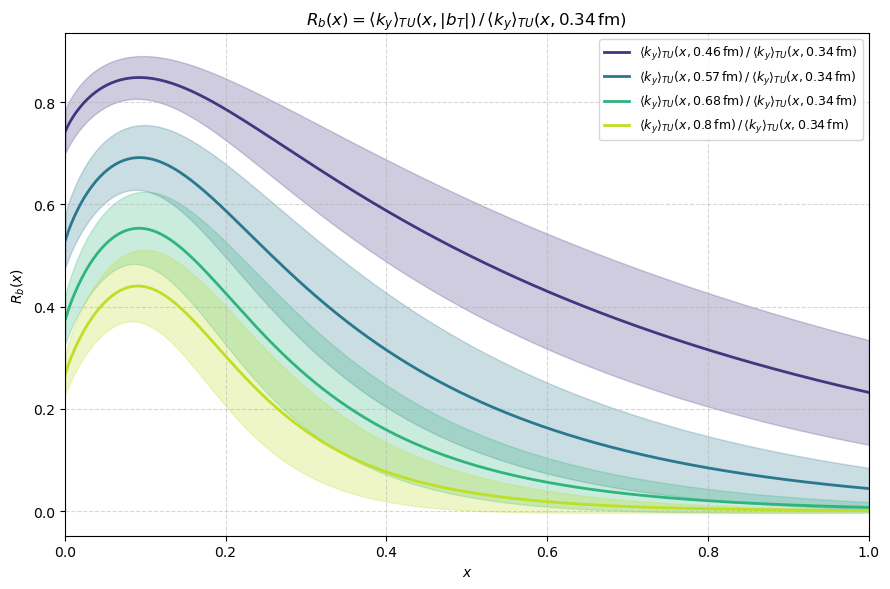

In [33]:
# ---------------------------------------------------------------------------
# Figure 1: R_b(x; b_i, b_ref) = <k_y>_TU(x,b_i) / <k_y>_TU(x,b_ref) -- ratio vs x
# Four |b_T| combinations, all against a common reference b_ref, on one plot.
# Flat in x <=> factorized. No pole/zero masking -- full raw ratio shown.
# ---------------------------------------------------------------------------
x_grid_fig1 = np.linspace(0.001, 1.0, 400)   # x in [0,1]; eval_obs_jk floors x=0 -> 1e-12 internally

b2_ref = 9.0                          # |b_T| ~ 0.34 fm (reference, smallest/most precise)
b2_fan = [16.0, 25.0, 36.0, 49.0]     # |b_T| ~ 0.46, 0.57, 0.68, 0.80 fm

bT_ref_fm = np.round(np.sqrt(b2_ref) * lata, 2)

obs_ref = eval_obs_jk(extrapolated_jk, x_grid_fig1, b2_ref)['siv']

fig1, ax1 = plt.subplots(figsize=(9, 6))
colors_fan = plt.cm.viridis(np.linspace(0.15, 0.9, len(b2_fan)))

for c, b2_i in zip(colors_fan, b2_fan):
    bT_i_fm = np.round(np.sqrt(b2_i) * lata, 2)
    obs_i = eval_obs_jk(extrapolated_jk, x_grid_fig1, b2_i)['siv']

    ratio_jk = obs_i / obs_ref
    m, e = jk_stats(ratio_jk, axis=0)

    label = (
        fr"$\langle k_y \rangle_{{TU}}(x,{bT_i_fm}\,{{\rm fm}})\,/\,"
        fr"\langle k_y \rangle_{{TU}}(x,{bT_ref_fm}\,{{\rm fm}})$"
    )
    ax1.plot(x_grid_fig1, m, color=c, linewidth=2, label=label)
    ax1.fill_between(x_grid_fig1, m - e, m + e, color=c, alpha=0.25)

ax1.set_title(
    r'$R_b(x) = \langle k_y \rangle_{TU}(x,|b_T|) \,/\, '
    fr'\langle k_y \rangle_{{TU}}(x,{bT_ref_fm}\,{{\rm fm}})$'
)
ax1.set_xlabel('$x$')
ax1.set_ylabel(r'$R_b(x)$')
ax1.set_xlim(0, 1)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(fontsize=9)

plt.tight_layout()
plt.savefig("Factorization_Ratio_vs_x_4curves_P234_bmin3_eta610.pdf", format='pdf', bbox_inches='tight')
plt.show()


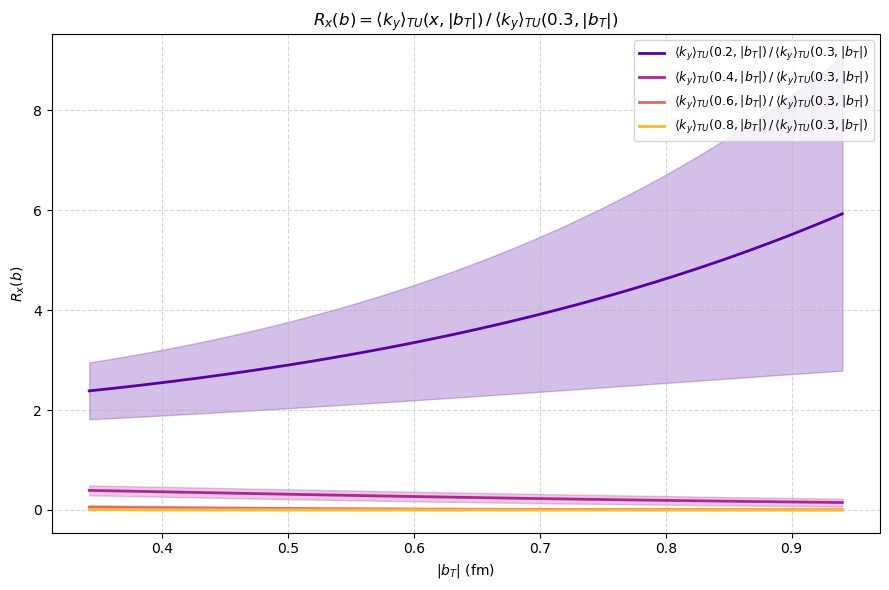

In [34]:
# ---------------------------------------------------------------------------
# Figure 2: R_x(b; x_i, x_ref) = <k_y>_TU(x_i,b) / <k_y>_TU(x_ref,b) -- ratio vs |b_T|
# Four x combinations, all against a common reference x_ref, on one plot.
# Flat in |b_T| <=> factorized. No pole/zero masking -- full raw ratio shown.
# ---------------------------------------------------------------------------
b2_grid_fig2 = np.linspace(9.0, 68.0, 120)     # |b_T| in [0.34, 0.94] fm; full fit range (b2>=bminfit^2=9)
bT_grid_fig2 = np.sqrt(b2_grid_fig2) * lata

x_ref = 0.3                       # reference x (smallest, most precisely determined)
x_fan = [0.2, 0.4, 0.6, 0.8]       # fan of x values ratioed against x_ref

def eval_siv_over_b2(x_val, b2_grid):
    """Evaluate the Sivers shift at a single x for a grid of b^2, stacking into (N_JK, N_b)."""
    x_arr = np.array([x_val])
    out = []
    for b2 in b2_grid:
        res = eval_obs_jk(extrapolated_jk, x_arr, b2)
        out.append(res['siv'][:, 0])
    return np.stack(out, axis=1)  # (N_JK, N_b)

obs_ref_b = eval_siv_over_b2(x_ref, b2_grid_fig2)

fig2, ax2 = plt.subplots(figsize=(9, 6))
colors_fan_x = plt.cm.plasma(np.linspace(0.15, 0.85, len(x_fan)))

for c, x_i in zip(colors_fan_x, x_fan):
    obs_i_b = eval_siv_over_b2(x_i, b2_grid_fig2)

    ratio_jk_b = obs_i_b / obs_ref_b
    m_b, e_b = jk_stats(ratio_jk_b, axis=0)

    label = (
        fr"$\langle k_y \rangle_{{TU}}({x_i},|b_T|)\,/\,"
        fr"\langle k_y \rangle_{{TU}}({x_ref},|b_T|)$"
    )
    ax2.plot(bT_grid_fig2, m_b, color=c, linewidth=2, label=label)
    ax2.fill_between(bT_grid_fig2, m_b - e_b, m_b + e_b, color=c, alpha=0.25)

ax2.set_title(
    r'$R_x(b) = \langle k_y \rangle_{TU}(x,|b_T|) \,/\, '
    fr'\langle k_y \rangle_{{TU}}({x_ref},|b_T|)$'
)
ax2.set_xlabel('$|b_T|$ (fm)')
ax2.set_ylabel(r'$R_x(b)$')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("Factorization_Ratio_vs_bT_4curves_P234_bmin3_eta610.pdf", format='pdf', bbox_inches='tight')
plt.show()


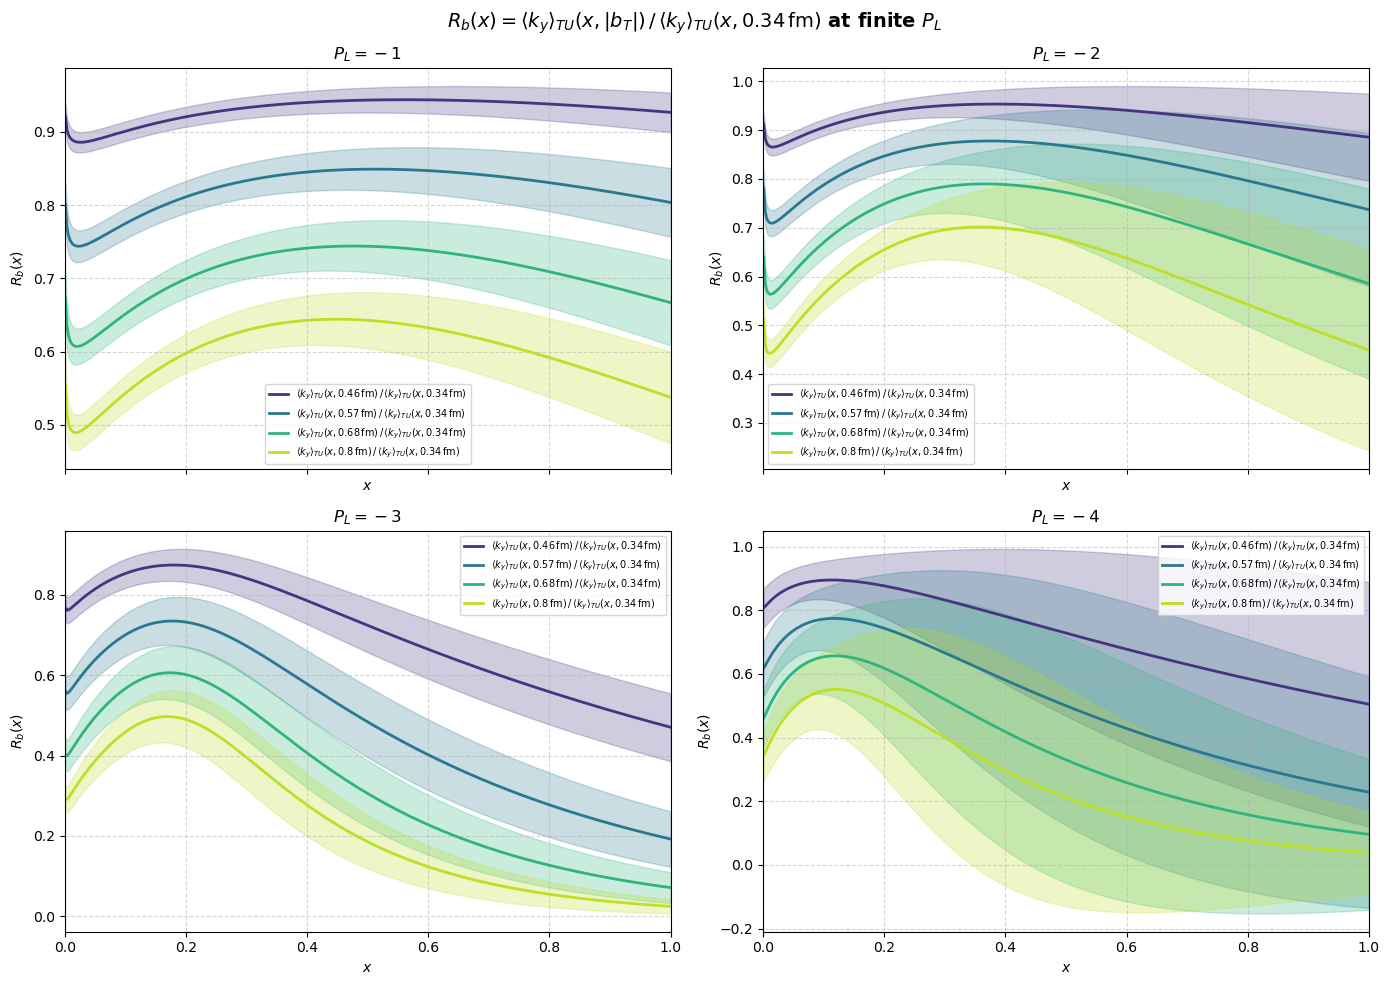

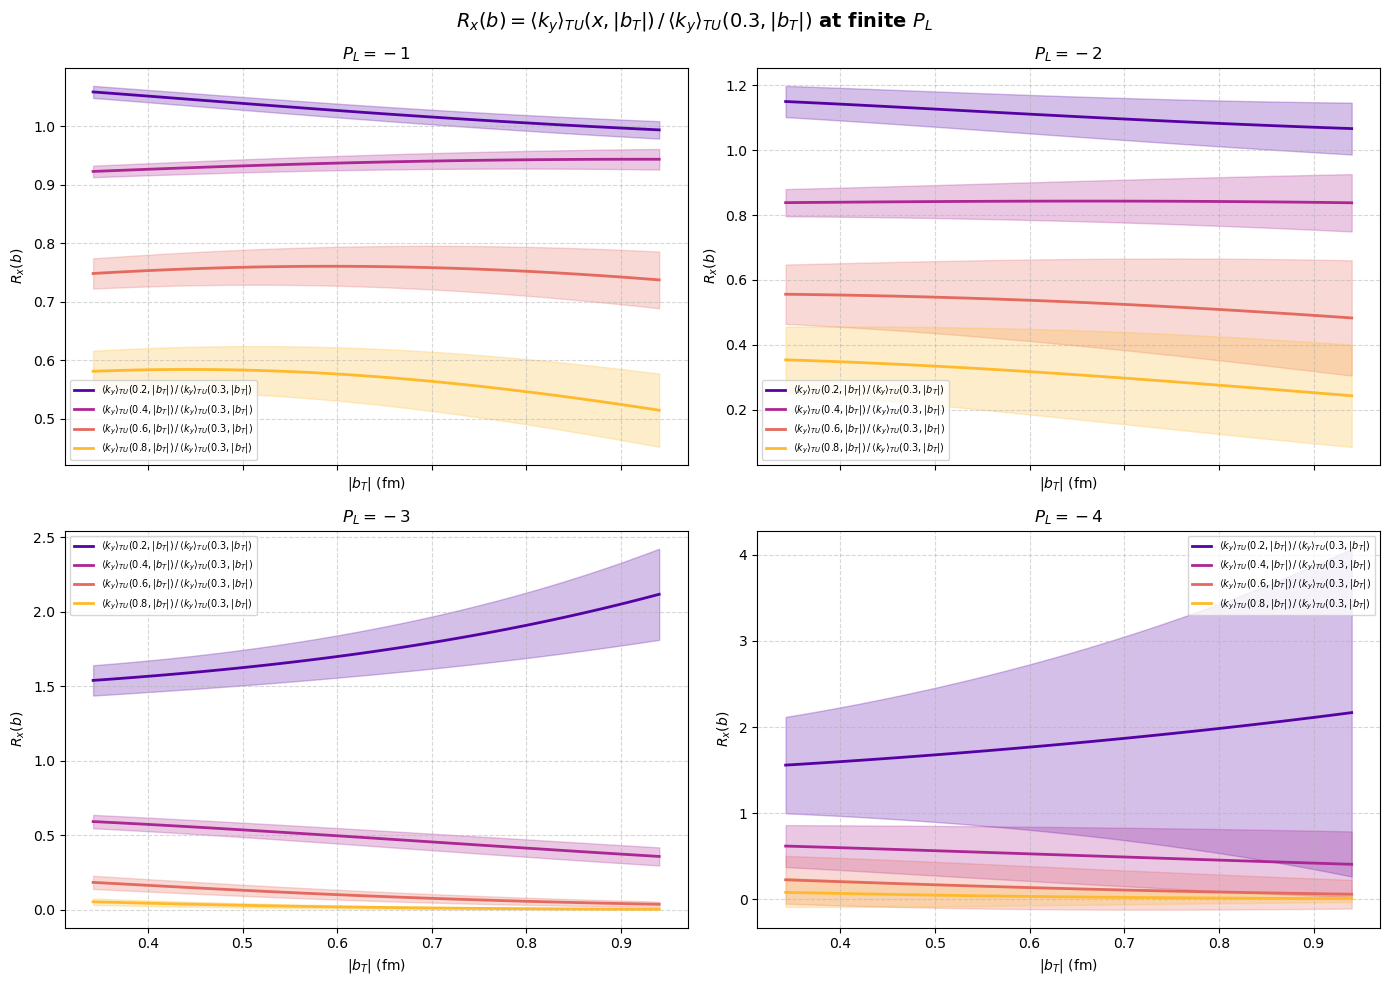

In [35]:
"""
Factorization ratio test for the Sivers shift, at each finite P_L individually
(no zeta_hat -> infinity extrapolation).

Same two ratio constructions as Factorization_Test_SiversShift.ipynb's Figures 1-2,
but evaluated directly on each P_L's raw fitted parameters:

    R_b(x) = <k_y>_TU(x,b_i) / <k_y>_TU(x,b_ref)   -- flat in x <=> factorized
    R_x(b) = <k_y>_TU(x_i,b) / <k_y>_TU(x_ref,b)   -- flat in b <=> factorized

Standalone: run directly with `python Factorization_Test_FinitePL.py`.
"""
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import kv, gamma

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
DATA_DIR = "/Users/hariprashadravikumar/Lattice_QCD_TMD_PhD/sivers_TMD_PhD_project/save_h5_A12B_A2B/TMD_fit/h5data"

lata = 0.11403  # lattice spacing in fm

bminfit = 3
etamin, etamax = 6, 10
PL_LIST = [-1, -2, -3, -4]

param_names = ['a_re', 'c_re', 'j_re', 'd_re',
               'a_im', 'c_im', 'j_im', 'd_im',
               'a_reA12B', 'c_reA12B', 'j_reA12B', 'd_reA12B']


# ---------------------------------------------------------------------------
# Helpers (copied verbatim from Factorization_Test_SiversShift.ipynb)
# ---------------------------------------------------------------------------
def Jackknife(datalist):
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N):
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N - 1) / N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)


def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            fitted_params[key] = param_group[key][:]
    return fitted_params


def jk_stats(arr, axis=0):
    """Vectorized jackknife mean/error over `axis` (the jackknife-sample axis)."""
    N = arr.shape[axis]
    m = np.mean(arr, axis=axis)
    e = np.sqrt(((N - 1) / N) * np.sum((arr - np.expand_dims(m, axis))**2, axis=axis))
    return m, e


# ---------------------------------------------------------------------------
# Load a single P_L's raw (unextrapolated) parameters, with the same
# per-P_L scaling rules used in Extrapolation_para_level.ipynb /
# Factorization_Test_SiversShift.ipynb's build_extrapolated_params().
# ---------------------------------------------------------------------------
def load_raw_params_for_pl(pl, data_dir=DATA_DIR):
    filename = f"{data_dir}/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{pl}.h5"
    params = load_params_from_h5(filename)

    p = {}
    p['a_re'] = params['a_re']
    p['c_re'] = params['c_re'] / (pl**2)
    p['j_re'] = params['j_re']
    p['d_re'] = params['d_re']

    p['a_im'] = params['a_im'] / pl
    p['c_im'] = params['c_im'] / (pl**2)
    p['j_im'] = params['j_im']
    p['d_im'] = params['d_im']

    p['a_reA12B'] = params['a_reA12B']
    p['c_reA12B'] = params['c_reA12B'] / (pl**2)
    p['j_reA12B'] = params['j_reA12B']
    p['d_reA12B'] = params['d_reA12B']

    return p


def load_massterm(data_dir=DATA_DIR):
    mass_filepath = f"{data_dir}/MassN_Jackknife.h5"
    with h5py.File(mass_filepath, "r") as f:
        MassN_jk = f["PL_-1"][:]
    return MassN_jk * (197.32698 * 0.001 / lata)


# ---------------------------------------------------------------------------
# Evaluate the Sivers shift on a grid of x at one fixed b^2, returning RAW
# per-jackknife-sample values (N_JK, N_x) -- ratios are formed from these
# before any jackknife reduction. Verbatim formulas from the notebook.
# ---------------------------------------------------------------------------
def eval_obs_jk(p_dict, x_grid, b2, massterm):
    x_grid = np.asarray(x_grid, dtype=float)
    abs_x = np.abs(x_grid).copy()
    abs_x[abs_x == 0] = 1e-12
    safe_x = np.where(x_grid == 0, 1e-12, x_grid)

    a_R, c_R = p_dict['a_re'][:, None], p_dict['c_re'][:, None]
    d_R, j_R = (1.0 + p_dict['d_re'] * b2)[:, None], p_dict['j_re'][:, None]

    a_I, c_I = p_dict['a_im'][:, None], p_dict['c_im'][:, None]
    d_I, j_I = (1.0 + p_dict['d_im'] * b2)[:, None], p_dict['j_im'][:, None]

    a_A, c_A = -p_dict['a_reA12B'][:, None], p_dict['c_reA12B'][:, None]
    d_A, j_A = (1.0 + p_dict['d_reA12B'] * b2)[:, None], p_dict['j_reA12B'][:, None]

    mt = massterm[:, None]

    cd_R = c_R / d_R
    t1_R = (2**(1 - j_R) * a_R * cd_R**(-0.25 - j_R / 2) * d_R**(-j_R)) / gamma(j_R)
    re = t1_R * (abs_x[None, :]**(-0.5 + j_R)) * kv(0.5 - j_R, abs_x[None, :] / np.sqrt(cd_R))

    cd_I = c_I / d_I
    t1_I = (2**(1 - j_I) * a_I * cd_I**(0.25 * (-3 - 2 * j_I)) * d_I**(-j_I)) / gamma(j_I)
    im = t1_I * (safe_x[None, :] * abs_x[None, :]**(-1.5 + j_I)) * kv(1.5 - j_I, np.sqrt(d_I / c_I) * abs_x[None, :])

    cd_A = c_A / d_A
    t1_A = (2**(1 - j_A) * a_A * cd_A**(-0.25 - j_A / 2) * d_A**(-j_A)) / gamma(j_A)
    reA12B = -2 * t1_A * (abs_x[None, :]**(-0.5 + j_A)) * kv(0.5 - j_A, abs_x[None, :] / np.sqrt(cd_A))

    denom = re - im                  # raw (re - im), matches reference convention
    f1Tperp = reA12B
    siv = mt * f1Tperp / denom       # <k_y>_TU

    return {'siv': siv}


def eval_siv_over_b2(p_dict, x_val, b2_grid, massterm):
    """Evaluate the Sivers shift at a single x for a grid of b^2, stacking into (N_JK, N_b)."""
    x_arr = np.array([x_val])
    out = []
    for b2 in b2_grid:
        res = eval_obs_jk(p_dict, x_arr, b2, massterm)
        out.append(res['siv'][:, 0])
    return np.stack(out, axis=1)  # (N_JK, N_b)


# ---------------------------------------------------------------------------
# Figure A: ratio vs x at fixed |b_T|, one 2x2 subplot per P_L
# ---------------------------------------------------------------------------
def make_figure_ratio_vs_x(pl_params, massterm):
    x_grid = np.linspace(0.001, 1.0, 400)
    b2_ref = 9.0                          # |b_T| ~ 0.34 fm
    b2_fan = [16.0, 25.0, 36.0, 49.0]     # |b_T| ~ 0.46, 0.57, 0.68, 0.80 fm
    bT_ref_fm = np.round(np.sqrt(b2_ref) * lata, 2)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    colors_fan = plt.cm.viridis(np.linspace(0.15, 0.9, len(b2_fan)))

    for ax, pl in zip(axes.flatten(), PL_LIST):
        p_dict = pl_params[pl]
        obs_ref = eval_obs_jk(p_dict, x_grid, b2_ref, massterm)['siv']

        for c, b2_i in zip(colors_fan, b2_fan):
            bT_i_fm = np.round(np.sqrt(b2_i) * lata, 2)
            obs_i = eval_obs_jk(p_dict, x_grid, b2_i, massterm)['siv']

            ratio_jk = obs_i / obs_ref
            m, e = jk_stats(ratio_jk, axis=0)

            label = (
                fr"$\langle k_y \rangle_{{TU}}(x,{bT_i_fm}\,{{\rm fm}})\,/\,"
                fr"\langle k_y \rangle_{{TU}}(x,{bT_ref_fm}\,{{\rm fm}})$"
            )
            ax.plot(x_grid, m, color=c, linewidth=2, label=label)
            ax.fill_between(x_grid, m - e, m + e, color=c, alpha=0.25)

        ax.set_title(f"$P_L = {pl}$")
        ax.set_xlabel('$x$')
        ax.set_ylabel(r'$R_b(x)$')
        ax.set_xlim(0, 1)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=7)

    fig.suptitle(
        r'$R_b(x) = \langle k_y \rangle_{TU}(x,|b_T|) \,/\, '
        fr'\langle k_y \rangle_{{TU}}(x,{bT_ref_fm}\,{{\rm fm}})$ at finite $P_L$',
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig("Factorization_Ratio_vs_x_AllPL_bmin3_eta610.pdf", format='pdf', bbox_inches='tight')
    return fig


# ---------------------------------------------------------------------------
# Figure B: ratio vs |b_T| at fixed x, one 2x2 subplot per P_L
# ---------------------------------------------------------------------------
def make_figure_ratio_vs_bT(pl_params, massterm):
    b2_grid = np.linspace(9.0, 68.0, 120)     # |b_T| in [0.34, 0.94] fm
    bT_grid = np.sqrt(b2_grid) * lata
    x_ref = 0.3
    x_fan = [0.2, 0.4, 0.6, 0.8]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    colors_fan_x = plt.cm.plasma(np.linspace(0.15, 0.85, len(x_fan)))

    for ax, pl in zip(axes.flatten(), PL_LIST):
        p_dict = pl_params[pl]
        obs_ref_b = eval_siv_over_b2(p_dict, x_ref, b2_grid, massterm)

        for c, x_i in zip(colors_fan_x, x_fan):
            obs_i_b = eval_siv_over_b2(p_dict, x_i, b2_grid, massterm)

            ratio_jk_b = obs_i_b / obs_ref_b
            m_b, e_b = jk_stats(ratio_jk_b, axis=0)

            label = (
                fr"$\langle k_y \rangle_{{TU}}({x_i},|b_T|)\,/\,"
                fr"\langle k_y \rangle_{{TU}}({x_ref},|b_T|)$"
            )
            ax.plot(bT_grid, m_b, color=c, linewidth=2, label=label)
            ax.fill_between(bT_grid, m_b - e_b, m_b + e_b, color=c, alpha=0.25)

        ax.set_title(f"$P_L = {pl}$")
        ax.set_xlabel('$|b_T|$ (fm)')
        ax.set_ylabel(r'$R_x(b)$')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=7)

    fig.suptitle(
        r'$R_x(b) = \langle k_y \rangle_{TU}(x,|b_T|) \,/\, '
        fr'\langle k_y \rangle_{{TU}}({x_ref},|b_T|)$ at finite $P_L$',
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig("Factorization_Ratio_vs_bT_AllPL_bmin3_eta610.pdf", format='pdf', bbox_inches='tight')
    return fig


if __name__ == "__main__":
    massterm = load_massterm()
    pl_params = {pl: load_raw_params_for_pl(pl) for pl in PL_LIST}

    make_figure_ratio_vs_x(pl_params, massterm)
    make_figure_ratio_vs_bT(pl_params, massterm)

    plt.show()
